# Решение задачи: ШАД ML-1, 2025, ДЗ 9 Стоимость недвижимости в Сиэтле
**Метод:** Градиентный бустинг (CatBoost)
**Метрика соревнования:** MAPE
**Автор:** Волосатов Артём

### Краткое описание решения:
1.  **Анализ данных (EDA):** Выявлена сильная гетероскедастичность (разброс цены растет с площадью).
2.  **Целевая переменная:** Вместо `price` предсказывается `Log(price / sqft_living)`. Это стабилизировало обучение и убрало "конус" в ошибках.
3.  **Feature Engineering:**
    * Добавлены географические признаки (расстояние до центра Сиэтла).
    * Добавлены относительные признаки (площадь дома к участку, размер комнат).
    * Использована дата (год/месяц) для учета тренда и сезонности.
4.  **Модель:** CatBoostRegressor с оптимизацией гиперпараметров (Optuna).
5.  **Валидация:** 5-Fold Cross-Validation для получения устойчивого OOF-прогноза.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Конфигурация
CONFIG = {
    'paths': {
        'train': 'train.csv',
        'test': 'test.csv',
        'sample_submission': 'sample_submission.csv',
        'submission_file': 'submission.csv'
    },
    'target_col': 'price',
    'id_col': 'id',
    'random_state': 42,
    'n_splits': 5
}

BEST_PARAMS = {
    'iterations': 2000,   # С запасом
    'learning_rate': 0.45,
    'depth': 6,
    'loss_function': 'RMSE',  # Оптимизируем RMSE для Логарифма таргета
    'eval_metric': 'RMSE',
    'random_seed': CONFIG['random_state'],
    'early_stopping_rounds': 100,
    'verbose': 200,
    'l2_leaf_reg': 5.635323347296876,
    'random_strength': 3.2972153432219042,
    'bagging_temperature': 0.2985519251720856
}


In [2]:
def load_data(config):
    """Загрузка данных и первичная предобработка."""
    train_df = pd.read_csv(config['paths']['train'])
    test_df = pd.read_csv(config['paths']['test'])

    # Сохраняем таргет
    target = train_df[config['target_col']]

    # Удаляем ID и Таргет из фичей
    # (ID не несет полезной информации для модели)
    train_df = train_df.drop([config['target_col'], config['id_col']], axis=1)
    test_df = test_df.drop(config['id_col'], axis=1)

    # Объединяем для единообразного Feature Engineering
    train_df['is_test'] = 0
    test_df['is_test'] = 1
    all_data = pd.concat([train_df, test_df], ignore_index=True)

    return all_data, target


all_data_raw, target = load_data(CONFIG)
print(f"Data loaded. Shape: {all_data_raw.shape}")

Data loaded. Shape: (22626, 20)


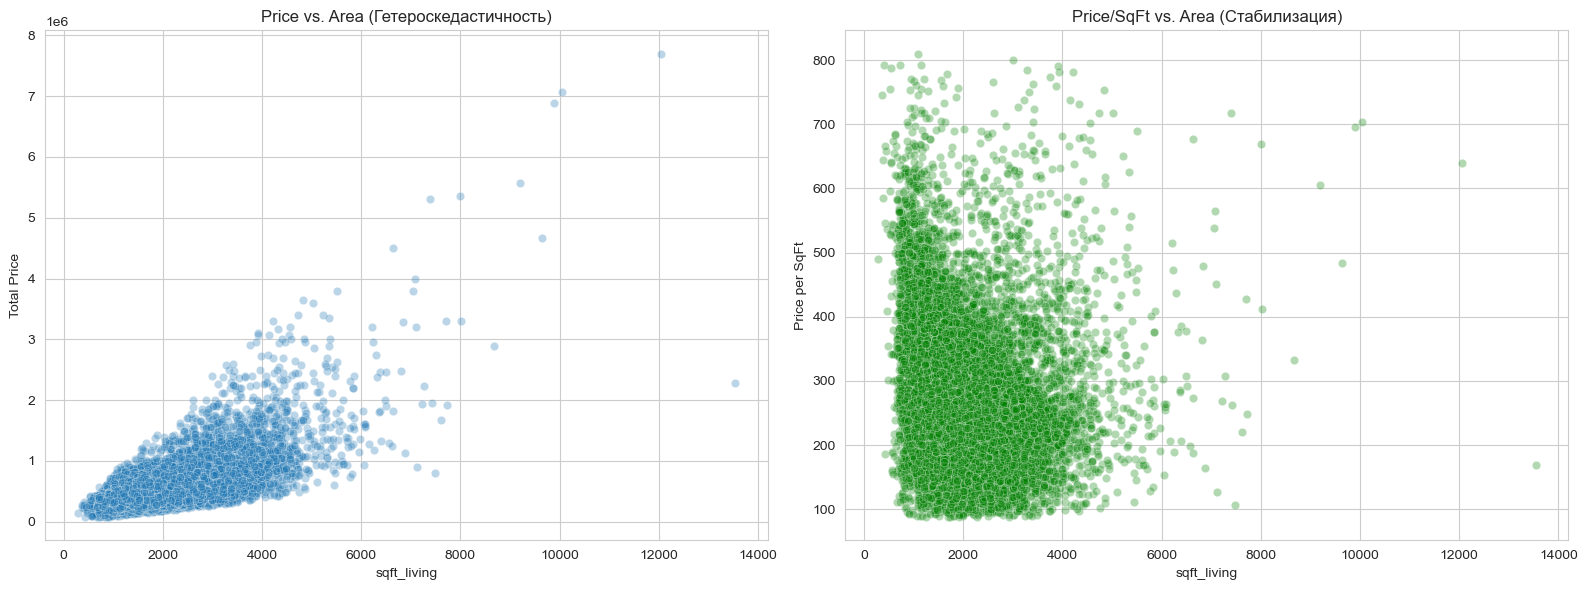

In [3]:
# Подготовка данных для графиков
eda_df = all_data_raw[all_data_raw['is_test'] == 0].copy()
eda_df['price'] = target
eda_df['price_per_sqft'] = eda_df['price'] / eda_df['sqft_living']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: "Конус" (Проблема)
sns.scatterplot(data=eda_df, x='sqft_living', y='price', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs. Area (Гетероскедастичность)')
axes[0].set_ylabel('Total Price')

# График 2: Решение (Price per SqFt)
sns.scatterplot(data=eda_df, x='sqft_living', y='price_per_sqft',
                alpha=0.3, color='green', ax=axes[1])
axes[1].set_title('Price/SqFt vs. Area (Стабилизация)')
axes[1].set_ylabel('Price per SqFt')

plt.tight_layout()
plt.show()


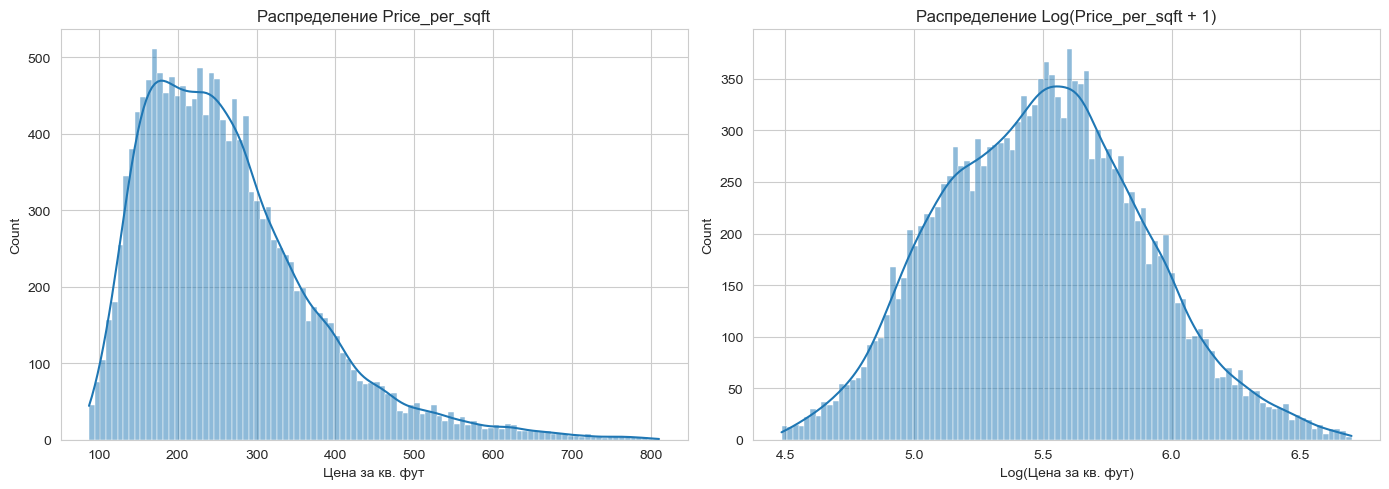

In [4]:
plt.figure(figsize=(14, 5))

# График 1: Распределение Price_per_sqft
plt.subplot(1, 2, 1)
sns.histplot(eda_df['price_per_sqft'], kde=True, bins=100)
plt.title('Распределение Price_per_sqft')
plt.xlabel('Цена за кв. фут')

# График 2: Логарифм Price_per_sqft
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(eda_df['price_per_sqft']), kde=True, bins=100)
plt.title('Распределение Log(Price_per_sqft + 1)')
plt.xlabel('Log(Цена за кв. фут)')

plt.tight_layout()
plt.show()

Цена за фут ведёт себя гораздо стабильнее, чем цена покупки. Смена таркета с цены на цену за фут улучшил MAPE с 32% до 16%
Переход от цены за фут к логарифму цены за фут улучшил MAPE с 16% до 11.5%.

Правильный выбор таргета - это главная часть этого решения.

In [5]:
def create_features(df_):
    """
    Генерация признаков. Включает:
    1. Парсинг даты (Тренд + Сезонность)
    2. Гео-фичи (Расстояние до центра)
    3. Относительные величины (Ratios)
    """
    df = df_.copy()

    # --- 1. Работа с датой ---
    df['date'] = pd.to_datetime(df['date'])
    df['sell_year'] = df['date'].dt.year
    df['sell_month'] = df['date'].dt.month
    # Удаляем сырую дату
    df = df.drop('date', axis=1)

    # --- 2. География ---
    # Zipcode как категория
    df['zipcode'] = df['zipcode'].astype(str)

    # Расстояние до центра Сиэтла (Space Needle: 47.6062, -122.3321)
    # Коэффициенты 111 и 75 - примерный перевод градусов в км
    seattle_lat = 47.6062
    seattle_long = -122.3321
    lat_diff = (df['lat'] - seattle_lat) * 111
    long_diff = (df['long'] - seattle_long) * 75
    df['dist_to_center'] = np.sqrt(lat_diff**2 + long_diff**2)

    # --- 3. Относительные признаки (Ratios) ---
    # Плотность застройки (меньше -> больше земли -> дороже метр)
    df['living_to_lot_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)

    # Просторность (больше -> элитнее -> дороже метр)
    df['avg_room_size'] = df['sqft_living'] / \
        (df['bedrooms'] + df['bathrooms'] + 1)

    # Сравнение с соседями
    df['living_rel_neighbors'] = df['sqft_living'] / (df['sqft_living15'] + 1)

    return df


# Применяем пайплайн
print("Generating features...")
all_data_processed = create_features(all_data_raw)
print("Done.")

Generating features...
Done.


Тут не совсем финальный прогон, в конце поиграл в тюнинг параметров и проиграл

In [6]:
def run_training():
    # 1. Подготовка данных
    X_train = all_data_processed[all_data_processed['is_test'] == 0].drop(
        'is_test', axis=1)
    X_test = all_data_processed[all_data_processed['is_test'] == 1].drop(
        'is_test', axis=1)

    # 2. Трансформация Таргета (Price -> Price/SqFt)
    # Это ключевой элемент нашей стратегии
    y_train_price = target
    y_train_ppsf = y_train_price / (X_train['sqft_living'] + 1e-6)

    # 3. Определение категорий
    cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
    print(f"Cat features: {cat_features}")

    # 4. KFold Loop
    kf = KFold(n_splits=CONFIG['n_splits'], shuffle=True,
               random_state=CONFIG['random_state'])

    oof_preds_ppsf = np.zeros(len(X_train))
    test_preds_ppsf = np.zeros(len(X_test))

    for fold, (idx_tr, idx_val) in enumerate(kf.split(X_train, y_train_ppsf)):
        print(f"--- Fold {fold+1} ---")

        X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
        y_tr, y_val = y_train_ppsf.iloc[idx_tr], y_train_ppsf.iloc[idx_val]

        # Log-трансформация внутри фолда (для нормализации остатков)
        train_pool = Pool(X_tr, np.log1p(y_tr), cat_features=cat_features)
        val_pool = Pool(X_val, np.log1p(y_val), cat_features=cat_features)
        test_pool = Pool(X_test, cat_features=cat_features)

        model = CatBoostRegressor(**BEST_PARAMS)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

        # Обратная трансформация (Expm1)
        oof_preds_ppsf[idx_val] = np.expm1(model.predict(val_pool))
        test_preds_ppsf += np.expm1(model.predict(test_pool)
                                    ) / CONFIG['n_splits']

    # Коррекция
    oof_preds_ppsf[oof_preds_ppsf < 0] = 0
    test_preds_ppsf[test_preds_ppsf < 0] = 0

    # Оценка качества (MAPE на price_per_sqft эквивалентна MAPE на price)
    score = mean_absolute_percentage_error(y_train_ppsf, oof_preds_ppsf)
    print(f"\n✅ Final OOF MAPE: {score:.6f}")

    return test_preds_ppsf, X_test


# Запуск
test_preds_ppsf, X_test_processed = run_training()

Cat features: ['zipcode']
--- Fold 1 ---
0:	learn: 0.3112470	test: 0.3028466	best: 0.3028466 (0)	total: 201ms	remaining: 6m 42s
200:	learn: 0.1153658	test: 0.1625093	best: 0.1618393 (120)	total: 11.6s	remaining: 1m 43s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1618393037
bestIteration = 120

Shrink model to first 121 iterations.
--- Fold 2 ---
0:	learn: 0.3146601	test: 0.3224727	best: 0.3224727 (0)	total: 90.1ms	remaining: 3m
200:	learn: 0.1143156	test: 0.1652109	best: 0.1641579 (166)	total: 11.4s	remaining: 1m 42s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1641578612
bestIteration = 166

Shrink model to first 167 iterations.
--- Fold 3 ---
0:	learn: 0.3172959	test: 0.3132487	best: 0.3132487 (0)	total: 60.6ms	remaining: 2m 1s
200:	learn: 0.1152402	test: 0.1613122	best: 0.1599907 (141)	total: 12.6s	remaining: 1m 52s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1599907039
bestIteration = 141

Shrink model to fir

In [8]:
# 1. Конвертация обратно в полную цену
# Price = Price_per_sqft * Sqft_living
final_predictions = test_preds_ppsf * \
    (X_test_processed['sqft_living'].values + 1e-6)

# 2. Создание файла
# Kaggle требует колонку 'index' от 1 до 7000
submission = pd.DataFrame({
    'index': np.arange(1, 7001),
    'price': final_predictions
})

filename = 'submission.csv'
submission.to_csv(filename, index=False)

print(f"Submission saved successfully to '{filename}'")
submission.head()

Submission saved successfully to 'submission.csv'


,index,price
0,1,290567.141742
1,2,981575.954653
2,3,182248.705368
3,4,466945.079754
4,5,275927.081833
